In [71]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import random
import torch

In [3]:
def f(x):
    return 3*x**2 - 4*x + 5

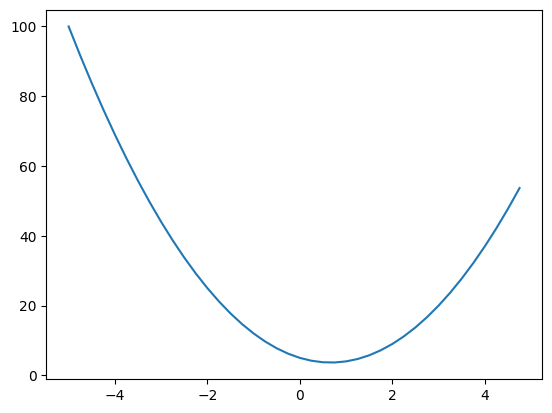

In [4]:
xs = np.arange(-5, 5, .25)
ys = f(xs)
plt.plot(xs, ys)


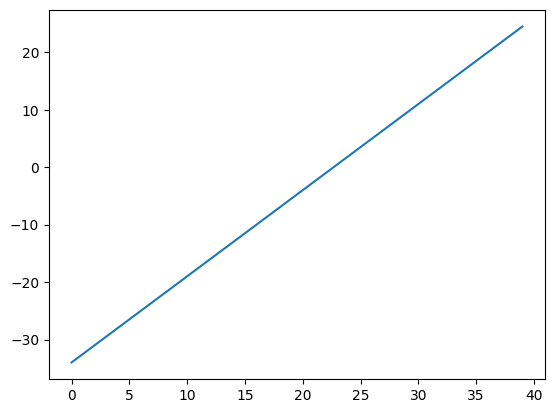

In [5]:
h = .0000000001
x = 3.0
(f(x + h) - f(x))/h #limit definition of derivative
#remember f is our function defined above
plt.plot((f(xs + h) - f(xs)) / h)

In [6]:
#more complex case
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [7]:
h = .0001

#inputs. we're going to evaluate deriv of d wrt each input
a = 2.0
b = -3.0
c = 10.0

d = a*b + c
a += h
da = a*b + c
a -= h
b += h
db = a*b + c
b -= h
c += h
dc = a*b + c


print('dd/da', ((da-d)/ h))
print('dd/db', ((db-d)/ h))
print('dd/dc', ((dc-d)/ h))
#same thing as above. we're bumping d by a small amount and then normalizing the difference by that small amount
#mathematically, dd/da = b and b = -3; dd/db = 2; dd/dc = 1

dd/da -3.000000000010772
dd/db 2.0000000000042206
dd/dc 0.9999999999976694


In [ ]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    #otherwise it would return the memory address of the Value object when we perform an operation
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
    
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += (other * self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out
    
    def __rmul__(self, other): # makes __mul__ commutative
        return self * other
    
    def __truediv__(self, other): # self / other
        return self * (other**(-1))
    
    def __neg__(self): # -self
        return self * -1
    
    def __sub__(self, other): # self - other
        return self + (-other)
    
    def __radd__(self, other): #needed to fix sum() in loss function
        return self + other
    
    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1)/(math.exp(2*n) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad 
        out._backward = _backward
        return out
    
    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [9]:
from graphviz import Digraph

def trace(root):
  #builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    #for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data=%.4f | grad=%.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      #if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      #and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    #connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [46]:
#inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
#weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
#bias of the neuron
b = Value(6.88137, label='b')
#x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

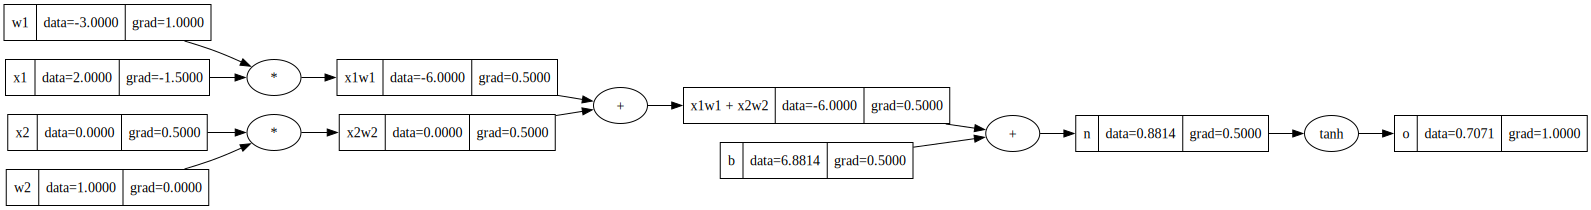

In [47]:
draw_dot(o)

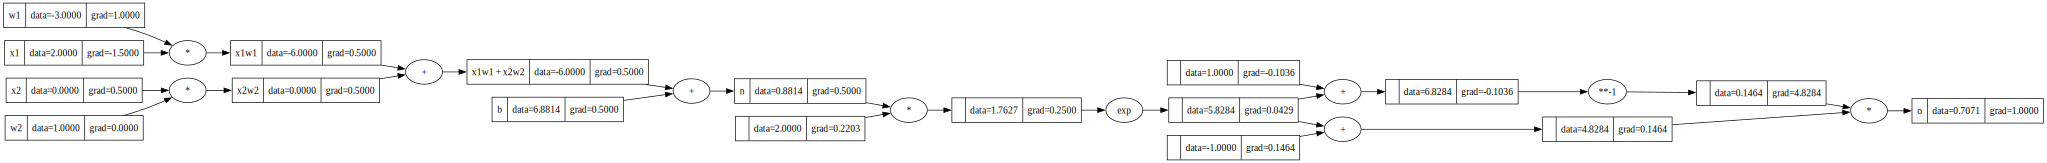

In [63]:
#inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
#weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
#bias of the neuron
b = Value(6.88137, label='b')
#x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'

#---
e = (2*n).exp()
o = (e - 1) / (e + 1)
#---
o.label = 'o'
o.backward()
draw_dot(o)

In [ ]:
# same thing using pytorch
# micrograd is scalar-based, pytorch based on n-dimensional tensors

#cast to double so we get float64 which is python default
#these would be float32 by default
#pytorch also will think these don't require gradients by default since they're leaf nodes
x1 = torch.Tensor([2.0]).double() ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double() ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double() ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double() ; w2.requires_grad = True
b = torch.Tensor([6.88137]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())


0.7071050214706146
---
x2 0.5000024886110417
w2 0.0
x1 -1.500007465833125
w1 1.0000049772220834


In [70]:
torch.Tensor([[1, 2, 3], [4, 5, 6]]).shape

torch.Size([2, 3])

In [102]:

class Neuron:

    def __init__(self, nin): #nin is number of inputs
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b) #activation function
        out = act.tanh() #tanh is the squish function
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        #params = []
        #for neuron in self.neurons:
            #ps = neuron.parameters()
            #params.extens(ps)
        #return params
    
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [145]:
#example of the classes above

x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.9683165551562515)

In [146]:
# example dataset for classifier neural net
# given each example row in x, it should output the corresponding y value
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] #desired targets

In [156]:
#training loop
for k in range(20):
    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred)) #python sum() does 0 + sum()

    #backward pass
    for p in n.parameters():
        p.grad = 0.0 #need to reset gradients to zero or they will keep adding! remember all the grads do +=
    loss.backward()

    #update
    for p in n.parameters():
        p.data += -.01 * p.grad

    print(k, loss.data)

0 0.04791384460447498
1 0.047353900752582126
2 0.04680572761015285
3 0.04626897444036045
4 0.04574330391932299
5 0.04522839151332459
6 0.04472392488991716
7 0.04422960336079211
8 0.04374513735446611
9 0.043270247916955995
10 0.042804666238744654
11 0.042348133206455946
12 0.041900398977760656
13 0.041461222578140014
14 0.041030371518217895
15 0.04060762143046502
16 0.04019275572414967
17 0.03978556525748945
18 0.039385848026020916
19 0.03899340886626972


In [157]:
ypred

[Value(data=0.9067118706390711),
 Value(data=-0.9582004538581598),
 Value(data=-0.8686494979721044),
 Value(data=0.8937428715522375)]